In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Cell 1: Install required packages
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'robustbench', 'timm', 'einops', '-q'], check=False)

# Fix autoattack import issue that robustbench depends on
import types
mock_aa = types.ModuleType('autoattack')
mock_aa_state = types.ModuleType('autoattack.state')
mock_aa_state.EvaluationState = type('EvaluationState', (), {})
mock_aa.state = mock_aa_state
mock_aa.AutoAttack = type('AutoAttack', (), {'__init__': lambda *a, **kw: None})
sys.modules['autoattack'] = mock_aa
sys.modules['autoattack.state'] = mock_aa_state

print('Environment ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.9 MB/s eta 0:00:00
Environment ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [3]:
# Cell 2: Imports and setup
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import DataLoader, TensorDataset
from robustbench.data import load_cifar10c
from robustbench.utils import load_model

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
# Cell 3: Dataset configuration
# All 15 standard CIFAR-10-C corruptions
CORRUPTIONS = [
    'gaussian_noise', 'shot_noise', 'impulse_noise',       # Noise
    'defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur',  # Blur
    'snow', 'frost', 'fog', 'brightness',                  # Weather
    'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'  # Digital
]

CORRUPTION_CATEGORIES = {
    'Noise':   ['gaussian_noise', 'shot_noise', 'impulse_noise'],
    'Blur':    ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
    'Weather': ['snow', 'frost', 'fog', 'brightness'],
    'Digital': ['contrast', 'elastic_transform', 'pixelate', 'jpeg_compression']
}

N_EXAMPLES = 1000   # per corruption (use 10000 for full eval)
BATCH_SIZE = 64
SEVERITY = 5        # hardest severity level
DATA_DIR = './data'

print(f'Evaluating on {len(CORRUPTIONS)} corruptions at severity {SEVERITY}')

Evaluating on 15 corruptions at severity 5


Loading sample images from CIFAR-10-C...
Starting download from https://zenodo.org/api/records/2535967/files/CIFAR-10-C.tar/content


44533it [02:52, 258.29it/s]                           


Download finished, extracting...
Downloaded and extracted.


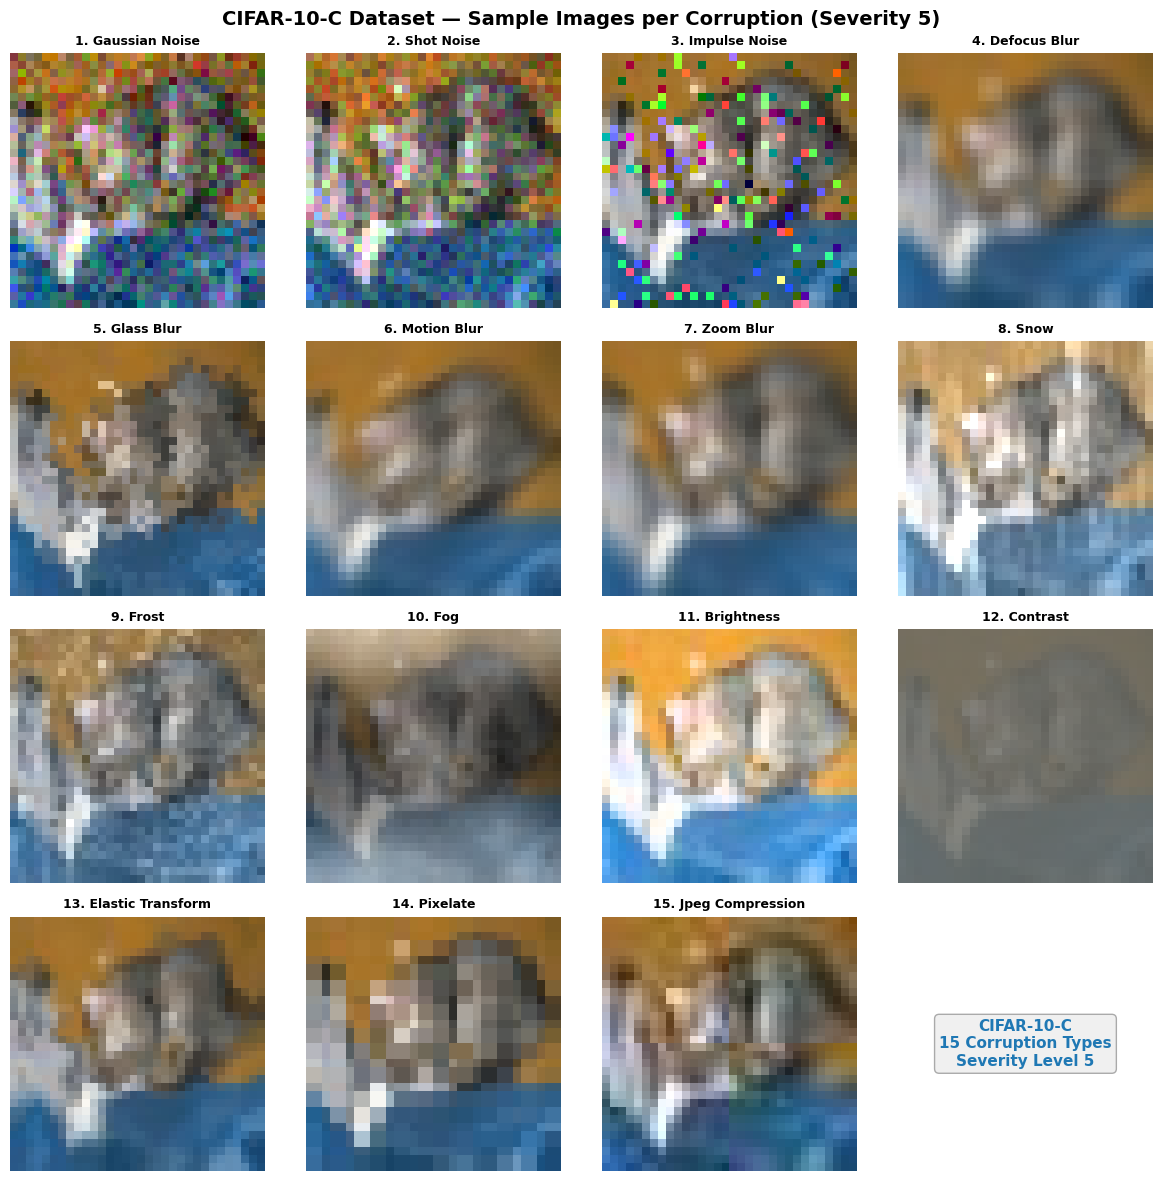

Saved: phase1_corruption_samples.png


In [5]:
# Cell 4: Visualize corruption types
print('Loading sample images from CIFAR-10-C...')
samples = {}
for corr in CORRUPTIONS:
    x, _ = load_cifar10c(n_examples=1, corruptions=[corr], severity=SEVERITY, data_dir=DATA_DIR)
    samples[corr] = np.clip(x[0].permute(1,2,0).numpy(), 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()
for i, corr in enumerate(CORRUPTIONS):
    axes[i].imshow(samples[corr])
    axes[i].set_title(f'{i+1}. {corr.replace("_"," ").title()}', fontsize=9, fontweight='bold')
    axes[i].axis('off')
axes[15].axis('off')
axes[15].text(0.5, 0.5, 'CIFAR-10-C\n15 Corruption Types\nSeverity Level 5',
              ha='center', va='center', fontsize=11, fontweight='bold', color='#1f78b4',
              bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#aaa'))
plt.suptitle('CIFAR-10-C Dataset — Sample Images per Corruption (Severity 5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_corruption_samples.png', dpi=150)
plt.show()
print('Saved: phase1_corruption_samples.png')

In [6]:
# Cell 5: Load pretrained source model
print('Loading pretrained WideResNet-28-10...')
source_model = load_model(
    model_name='Standard',
    dataset='cifar10',
    threat_model='corruptions'
).to(DEVICE).eval()

total_params = sum(p.numel() for p in source_model.parameters())
trainable_params = sum(p.numel() for p in source_model.parameters() if p.requires_grad)
print(f'Model: WideResNet-28-10 (Standard)')
print(f'Total parameters : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

Loading pretrained WideResNet-28-10...


Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=33883717-ab3a-4694-b94b-025a3678a807
To: /kaggle/working/models/cifar10/corruptions/Standard.pt
100%|██████████| 292M/292M [00:02<00:00, 136MB/s]  


Model: WideResNet-28-10 (Standard)
Total parameters : 36,479,194
Trainable params : 36,479,194


In [7]:
# Cell 6: Source model evaluation (no adaptation)
def evaluate_model(model, loader, device):
    """Evaluate model accuracy on a DataLoader. No gradient updates."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100.0 * (1 - correct / total)  # return error %

print(f'Evaluating source model (no adaptation) on {N_EXAMPLES} samples per corruption...')
source_results = []

for corr in CORRUPTIONS:
    x, y = load_cifar10c(n_examples=N_EXAMPLES, corruptions=[corr], severity=SEVERITY, data_dir=DATA_DIR)
    loader = DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE, shuffle=False)
    err = evaluate_model(source_model, loader, DEVICE)
    source_results.append({'Corruption': corr, 'Source Model Error %': round(err, 2)})
    print(f'  {corr:<25} Error: {err:.2f}%')

df_source = pd.DataFrame(source_results)
print(f'\nMean Source Error: {df_source["Source Model Error %"].mean():.2f}%')

Evaluating source model (no adaptation) on 1000 samples per corruption...
  gaussian_noise            Error: 72.90%
  shot_noise                Error: 64.70%
  impulse_noise             Error: 71.90%
  defocus_blur              Error: 48.70%
  glass_blur                Error: 53.90%
  motion_blur               Error: 36.10%
  zoom_blur                 Error: 41.10%
  snow                      Error: 24.90%
  frost                     Error: 40.60%
  fog                       Error: 25.60%
  brightness                Error: 10.00%
  contrast                  Error: 48.90%
  elastic_transform         Error: 25.30%
  pixelate                  Error: 57.60%
  jpeg_compression          Error: 29.80%

Mean Source Error: 43.47%


In [8]:
# Cell 7: TENT implementation
class TentModel(nn.Module):
    """
    TENT: Test-Time Entropy Minimization.
    Adapts only the affine parameters (gamma, beta) of BatchNorm layers.
    Reference: Wang et al., ICLR 2021.
    """
    def __init__(self, model, optimizer):
        super().__init__()
        self.model = model
        self.optimizer = optimizer

    def forward(self, x):
        outputs = self.model(x)
        # Shannon entropy minimization loss
        probs = outputs.softmax(dim=1)
        loss = -(probs * outputs.log_softmax(dim=1)).sum(dim=1).mean()
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        return outputs


def configure_tent_model(model):
    """
    Configure model for TENT:
    - Freeze all parameters
    - Unfreeze BatchNorm affine parameters (weight + bias)
    - Set BN to use batch statistics (disable running stats)
    """
    model.eval()
    model.requires_grad_(False)
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.requires_grad_(True)
            m.track_running_stats = False
            m.running_mean = None
            m.running_var = None
    return model


print('TENT model class defined.')
# Count how many BN parameters will be adapted
test_model = configure_tent_model(copy.deepcopy(source_model))
bn_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f'Parameters adapted by TENT (BN only): {bn_params:,}')
print(f'Fraction of total params: {bn_params/total_params*100:.2f}%')

TENT model class defined.
Parameters adapted by TENT (BN only): 17,952
Fraction of total params: 0.05%


In [9]:
# Cell 8: Baseline TENT evaluation
def run_tent_experiment(base_model, corruptions, n_examples, batch_size, severity, data_dir, device,
                        lr=1e-3, reset_per_corruption=True):
    """
    Run TENT adaptation experiment.
    Args:
        reset_per_corruption: If True, reset model weights before each corruption (episodic).
                              If False, keep adapting across corruptions (continual).
    """
    results = []

    if not reset_per_corruption:
        # Continual: one shared model across all domains
        m = configure_tent_model(copy.deepcopy(base_model))
        opt = optim.Adam(m.parameters(), lr=lr)
        tent = TentModel(m, opt)

    for corr in corruptions:
        x, y = load_cifar10c(n_examples=n_examples, corruptions=[corr],
                             severity=severity, data_dir=data_dir)
        loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=False)

        if reset_per_corruption:
            # Episodic: fresh model for each corruption
            m = configure_tent_model(copy.deepcopy(base_model))
            opt = optim.Adam(m.parameters(), lr=lr)
            tent = TentModel(m, opt)

        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.enable_grad():
                out = tent(xb)
            correct += (out.argmax(dim=1) == yb).sum().item()

        err = 100.0 * (1 - correct / n_examples)
        results.append({'Corruption': corr, 'Error %': round(err, 2)})
        print(f'  {corr:<25} Error: {err:.2f}%')

    return pd.DataFrame(results)


print('Running Baseline TENT (episodic reset, lr=1e-3)...')
df_tent_baseline = run_tent_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    lr=1e-3, reset_per_corruption=True
)

print(f'\nMean TENT Error: {df_tent_baseline["Error %"].mean():.2f}%')

Running Baseline TENT (episodic reset, lr=1e-3)...
  gaussian_noise            Error: 26.70%
  shot_noise                Error: 25.50%
  impulse_noise             Error: 37.10%
  defocus_blur              Error: 12.20%
  glass_blur                Error: 33.30%
  motion_blur               Error: 13.30%
  zoom_blur                 Error: 12.60%
  snow                      Error: 17.30%
  frost                     Error: 17.90%
  fog                       Error: 15.40%
  brightness                Error: 7.70%
  contrast                  Error: 13.70%
  elastic_transform         Error: 23.20%
  pixelate                  Error: 20.30%
  jpeg_compression          Error: 27.60%

Mean TENT Error: 20.25%


In [10]:
# Cell 9: Source vs TENT comparison table
df_comparison = df_source.copy()
df_comparison['TENT Baseline Error %'] = df_tent_baseline['Error %'].values
df_comparison['Improvement'] = df_comparison['Source Model Error %'] - df_comparison['TENT Baseline Error %']

print('='*65)
print('         PHASE 1: SOURCE MODEL vs TENT BASELINE')
print('='*65)
print(df_comparison.to_string(index=False))
print('-'*65)
print(f'Mean Source Error : {df_comparison["Source Model Error %"].mean():.2f}%')
print(f'Mean TENT Error   : {df_comparison["TENT Baseline Error %"].mean():.2f}%')
print(f'Mean Improvement  : {df_comparison["Improvement"].mean():.2f}%')
print('='*65)

# Save results
df_comparison.to_csv('phase1_results.csv', index=False)
print('Saved: phase1_results.csv')

         PHASE 1: SOURCE MODEL vs TENT BASELINE
       Corruption  Source Model Error %  TENT Baseline Error %  Improvement
   gaussian_noise                  72.9                   26.7         46.2
       shot_noise                  64.7                   25.5         39.2
    impulse_noise                  71.9                   37.1         34.8
     defocus_blur                  48.7                   12.2         36.5
       glass_blur                  53.9                   33.3         20.6
      motion_blur                  36.1                   13.3         22.8
        zoom_blur                  41.1                   12.6         28.5
             snow                  24.9                   17.3          7.6
            frost                  40.6                   17.9         22.7
              fog                  25.6                   15.4         10.2
       brightness                  10.0                    7.7          2.3
         contrast                  48.9 

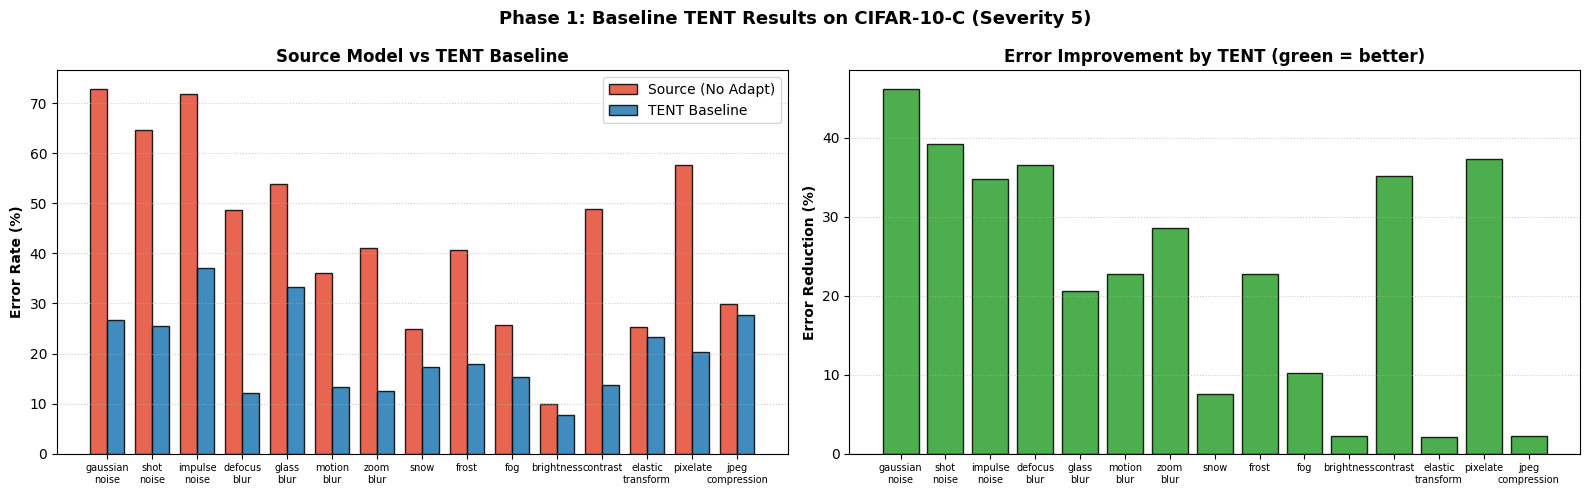

Saved: phase1_comparison.png


In [11]:
# Cell 10: Visualization — Source vs TENT Error
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart comparison
x = np.arange(len(CORRUPTIONS))
w = 0.38
axes[0].bar(x - w/2, df_comparison['Source Model Error %'], w,
            label='Source (No Adapt)', color='#e34a33', edgecolor='black', alpha=0.85)
axes[0].bar(x + w/2, df_comparison['TENT Baseline Error %'], w,
            label='TENT Baseline', color='#1f78b4', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', '\n') for c in CORRUPTIONS], fontsize=7)
axes[0].set_ylabel('Error Rate (%)', fontweight='bold')
axes[0].set_title('Source Model vs TENT Baseline', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Improvement bar
colors = ['#2ca02c' if v > 0 else '#d62728' for v in df_comparison['Improvement']]
axes[1].bar(x, df_comparison['Improvement'], color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('_', '\n') for c in CORRUPTIONS], fontsize=7)
axes[1].set_ylabel('Error Reduction (%)', fontweight='bold')
axes[1].set_title('Error Improvement by TENT (green = better)', fontweight='bold')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle('Phase 1: Baseline TENT Results on CIFAR-10-C (Severity 5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_comparison.png', dpi=150)
plt.show()
print('Saved: phase1_comparison.png')

In [12]:
# Cell 11: Summary
# Category-level summary
print('\n--- Error by Corruption Category ---')
for cat, corr_list in CORRUPTION_CATEGORIES.items():
    mask = df_comparison['Corruption'].isin(corr_list)
    src_mean = df_comparison.loc[mask, 'Source Model Error %'].mean()
    tent_mean = df_comparison.loc[mask, 'TENT Baseline Error %'].mean()
    print(f'  {cat:<10} Source: {src_mean:.2f}%   TENT: {tent_mean:.2f}%   Δ={src_mean-tent_mean:+.2f}%')

print('\n--- Phase 1 Complete ---')
print('Outputs: phase1_corruption_samples.png, phase1_comparison.png, phase1_results.csv')


--- Error by Corruption Category ---
  Noise      Source: 69.83%   TENT: 29.77%   Δ=+40.07%
  Blur       Source: 44.95%   TENT: 17.85%   Δ=+27.10%
  Weather    Source: 25.27%   TENT: 14.58%   Δ=+10.70%
  Digital    Source: 40.40%   TENT: 21.20%   Δ=+19.20%

--- Phase 1 Complete ---
Outputs: phase1_corruption_samples.png, phase1_comparison.png, phase1_results.csv
